In [1]:
import cv2
import matplotlib.pyplot as plt
import os

In [2]:
image = cv2.imread("images/sample.jpg")

if image is None:
    print("Image not found!")
else:
    print("Image loaded successfully.")

Image loaded successfully.


In [3]:
# Converting to Grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

In [4]:
# Binary Thresholding
_, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

In [5]:
# Adaptive Thresholding
adaptive = cv2.adaptiveThreshold(
    gray,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    11,
    2
)

In [6]:
# Otsu Thresholding
_, otsu = cv2.threshold(
    gray,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

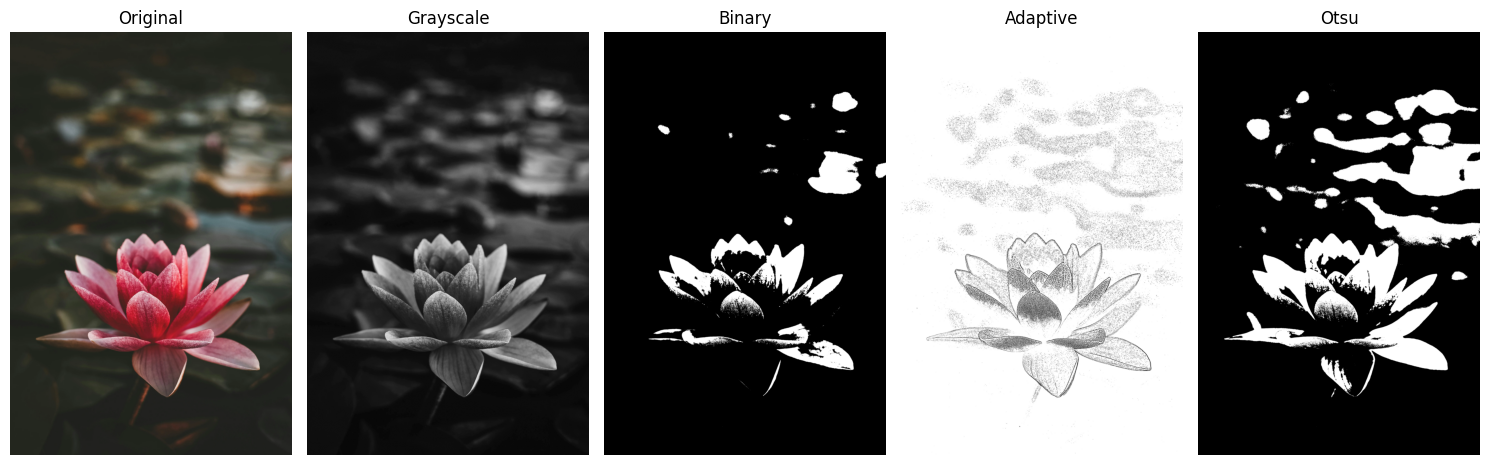

In [7]:
# Compare All Results
titles = [
    "Original",
    "Grayscale",
    "Binary",
    "Adaptive",
    "Otsu"
]

images = [
    cv2.cvtColor(image, cv2.COLOR_BGR2RGB),
    gray,
    binary,
    adaptive,
    otsu
]

plt.figure(figsize=(15,5))

for i in range(len(images)):
    plt.subplot(1,5,i+1)
    plt.imshow(images[i], cmap="gray")
    plt.title(titles[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [8]:
# simple foreground/background segmentation
foreground = binary.copy()
background = cv2.bitwise_not(binary)

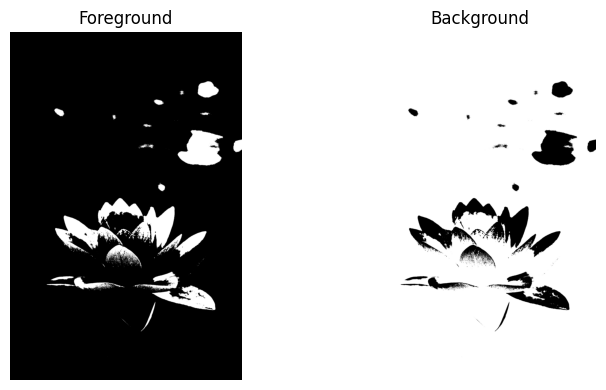

In [9]:
# Display foreground and background
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(foreground, cmap="gray")
plt.title("Foreground")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(background, cmap="gray")
plt.title("Background")
plt.axis("off")

plt.tight_layout()
plt.show()

In [10]:
# Save the output images
os.makedirs("output", exist_ok=True)

cv2.imwrite("output/grayscale.jpg", gray)
cv2.imwrite("output/binary.jpg", binary)
cv2.imwrite("output/adaptive.jpg", adaptive)
cv2.imwrite("output/otsu.jpg", otsu)
cv2.imwrite("output/foreground.jpg", foreground)
cv2.imwrite("output/background.jpg", background)

print("All output images saved successfully.")

All output images saved successfully.
